# CSAI3121 - Machine Learning and Intelligent Data Analysis
## Lab 2 - Simple and Multiple Linear Regression

<i>Based on the exercise from "Machine Learning with PyTorch and Scikit-Learn" book by Sebastian Raschka.</i>

In this 1-hour lab, you will use a small subset of the Ames Housing dataset to fit and compare two regression models for predicting `SalePrice`.

**Learning goals**
1. Load and prepare a real tabular dataset.
2. Use exploratory plots and correlations to choose useful predictors.
3. Fit a simple linear regression (SLR) model with one predictor.
4. Fit a multiple linear regression (MLR) model with several predictors.
5. Compare models using R^2, MSE, RMSE, and diagnostic plots.

The features we will use are:
- `Overall Qual`: overall material and finish rating from 1 (very poor) to 10 (excellent)
- `Overall Cond`: overall condition rating from 1 (very poor) to 10 (excellent)
- `Gr Liv Area`: above-ground living area in square feet
- `Central Air`: central air conditioning (N = no, Y = yes)
- `Total Bsmt SF`: total basement area in square feet
- `SalePrice`: sale price in U.S. dollars ($)

Work through the TODOs and answer the short reflection questions as you go.

---

### Step 1. Data Preprocessing (about 10 minutes)
In this section, you will:
- read the dataset
- inspect the first few rows and dimensions
- encode the categorical `Central Air` column
- check for missing values
- remove rows with missing values

In [187]:
import pandas as pd

In [188]:
# Read the data.
# We only load the columns needed for this lab.

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv('AmesHousing.csv', sep='	', usecols=columns)

# Display summary information about the dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Overall Cond   2930 non-null   int64  
 2   Total Bsmt SF  2929 non-null   float64
 3   Central Air    2930 non-null   str    
 4   Gr Liv Area    2930 non-null   int64  
 5   SalePrice      2930 non-null   int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 137.5 KB


In [189]:
# Display some first few rows of the data

df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [190]:
# Display the dimensions of the data: (number of rows, number of columns)

df.shape

(2930, 6)

In [191]:
# Convert the string values in Central Air into numeric values.
# N means no central air, Y means yes central air.

df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,1,1656,215000
1,5,6,882.0,1,896,105000
2,6,6,1329.0,1,1329,172000
3,7,5,2110.0,1,2110,244000
4,5,5,928.0,1,1629,189900


In [192]:
# Check whether each column has missing values.
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [193]:
# Remove rows that contain missing values.
# axis=0 means rows are removed.

df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [194]:
# Check the new dimensions after removing missing values.
df.shape

(2929, 6)

### Step 2. Data Visualization (about 15 minutes)
Exploratory data analysis (EDA) helps us understand the data before fitting a model.

In this section, you will:
- inspect pairwise relationships between variables
- compute correlations between all numeric variables
- identify candidate predictors for `SalePrice`

If time is short, focus first on the correlation heatmap.

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

<Figure size 800x600 with 0 Axes>

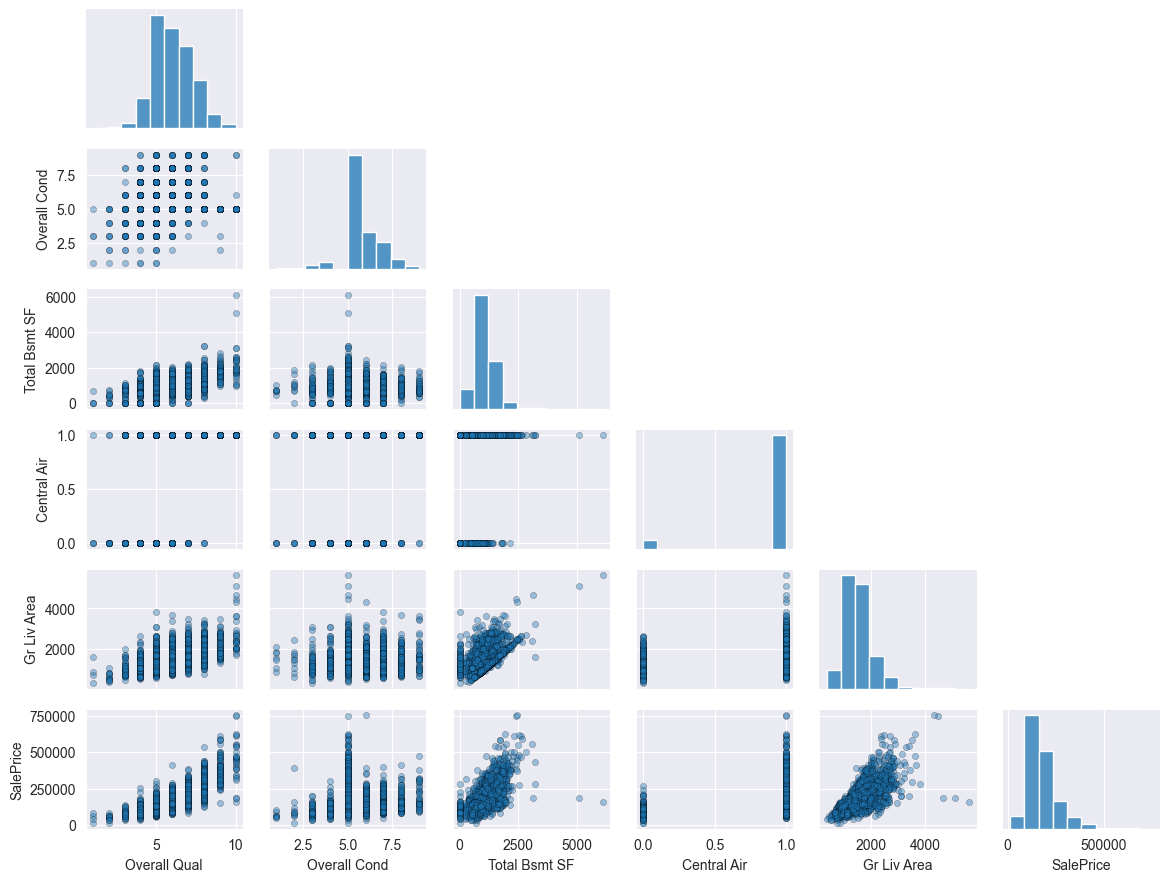

In [196]:
# Optional visual overview: pairwise scatterplots and histograms.
# This can take a few seconds to render.

plt.figure(figsize=(8, 6))
g = sns.PairGrid(df, diag_sharey=False, corner=True, height=1.5, aspect=1.3)
g.map_diag(sns.histplot, bins=10, edgecolor='white')
g.map_lower(sns.scatterplot, s=20, edgecolor='black', alpha=0.4)
plt.show()

<div style="background-color: #f0f8ff; padding: 10px; border-radius: 5px;">
  <h3 style="color: #0056b3;">Quick Check 1: EDA</h3>
  <p>Answer briefly before moving on:</p>
  <ol>
    <li>Which variable seems most strongly related to `SalePrice`?</li>
    <li>Do you notice any possible outliers?</li>
    <li>Are any predictors strongly correlated with each other?</li>
  </ol>
</div>

1. Overall Qual has the strongest relationship with SalePrice,
   with a correlation coefficient of 0.799, indicating a strong positive
   relationship.

2. The correlation matrix alone cannot identify outliers. Scatter plots
   or other methods such as IQR should be used to detect unusual observations.

3. No predictors show extremely strong correlation with each other.
   The highest correlation is between Overall Qual and Gr Liv Area
   (r ≈ 0.57), suggesting only moderate correlation.

In [197]:
# Compute the correlation matrix.
# Positive values close to 1 indicate strong positive correlation.
# Negative values close to -1 indicate strong negative correlation.

cm = df.corr()
cm

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
Overall Qual,1.000000,-0.094219,0.547294,0.287443,0.570304,0.799138
Overall Cond,-0.094219,1.000000,-0.173344,0.119611,-0.115176,-0.101191
Total Bsmt SF,0.547294,-0.173344,1.000000,0.218726,0.444675,0.632280
Central Air,0.287443,0.119611,0.218726,1.000000,0.123358,0.264700
Gr Liv Area,0.570304,-0.115176,0.444675,0.123358,1.000000,0.706628
SalePrice,0.799138,-0.101191,0.632280,0.264700,0.706628,1.000000


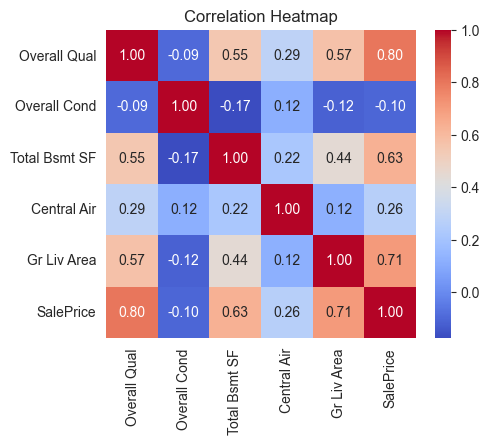

In [198]:
plt.figure(figsize=(5, 4))

# annot=True 标注数字
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Other available colormaps: rocket, mako, viridis, plasma, coolwarm

#### Think Before Modeling
Based on the correlation heatmap, choose one predictor for the simple linear regression model.

For this lab, we will start with `Gr Liv Area` because it is easy to interpret and usually has a clear relationship with `SalePrice`.

### Step 3. Simple Linear Regression (SLR) (about 15 minutes)
We will first fit a model with one predictor:

`SalePrice = intercept + slope * Gr Liv Area`

`statsmodels` is useful here because it gives a detailed regression summary, including coefficients, R^2 values, and p-values.

In [199]:
import statsmodels.api as sm

x = df[['Gr Liv Area']]
y = df['SalePrice']

# Add the intercept term.
x1 = sm.add_constant(x)

# Create and fit the OLS regression model.
olsm = sm.OLS(y, x1)
model = olsm.fit()

# View the fitted coefficients.
model.params
# SalePrice = 13342.978662 + 111.666258 × GrLivArea

const          13342.978662
Gr Liv Area      111.666258
dtype: float64

In [200]:
# A more comprehensive analysis result can be found in the summary.
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     2919.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:33:04   Log-Likelihood:                -36206.
No. Observations:                2929   AIC:                         7.242e+04
Df Residuals:                    2927   BIC:                         7.243e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.334e+04   3271.231      4.079      0.000    6928.832    1.98e+04
Gr Liv Area   111.6663      2.067     54.029      0.000     107.614     115.719
==============================================================================
Omnibus:                      491.815   Durbin-Watson:                   1.068
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5129.097
Skew:                           0.468   Prob(JB):                         0.00
Kurtosis:                       9.415   Cond. No.                     4.96e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.96e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

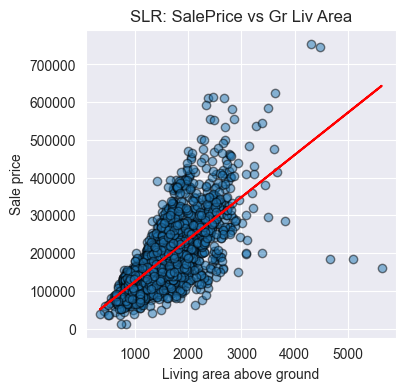

In [201]:
from sklearn.metrics import r2_score, mean_squared_error

# Generate the predicted SalePrice values.
y_pred = model.predict(x1)

plt.figure(figsize=(4, 4))
plt.scatter(x, y, edgecolor='black', alpha=0.5)
plt.plot(x, y_pred, color='red')
plt.xlabel('Living area above ground')
plt.ylabel('Sale price')
plt.title('SLR: SalePrice vs Gr Liv Area')
plt.show()

In [202]:
# Compute SLR evaluation metrics.

slr_r2 = r2_score(y, y_pred)
slr_mse = mean_squared_error(y, y_pred)
slr_rmse = slr_mse ** 0.5

print(f'SLR R^2: {slr_r2:.4f}')
print(f'SLR MSE: {slr_mse:.2f}')
print(f'SLR RMSE: ${slr_rmse:,.2f}')

SLR R^2: 0.4993
SLR MSE: 3193487567.35
SLR RMSE: $56,510.95


<div style="background-color: #f0f8ff; padding: 10px; border-radius: 5px;">
  <h3 style="color: #0056b3;">Quick Check 2: Interpret the SLR Model</h3>
  <p>Answer briefly before moving on:</p>
  <ol>
    <li>What does the slope for <code>Gr Liv Area</code> mean in words?</li>
    <li>Does the model explain all variation in house prices? How do you know?</li>
    <li>Is RMSE easier to interpret than MSE? Why?</li>
  </ol>
</div>


1. The slope of Gr Liv Area represents the average change in SalePrice for a one-unit increase in living area. For example, if the slope is 120, each additional square foot is associated with about a $120 increase in predicted house price.

2. No. The model does not explain all variation in house prices. The R² value shows the proportion of variation explained by the model. Since R² is less than 1, some variation remains unexplained.

3. Yes. RMSE is easier to interpret because it has the same unit as SalePrice (dollars), while MSE is expressed in squared units.

### Step 4. Multiple Linear Regression (MLR) (about 15 minutes)
Now fit a model using all available predictors except `SalePrice`.

Your task: modify the SLR pattern above to build the MLR model, print the summary, and compare the result with the SLR model.

In [203]:
multi_x = df.drop(columns=['SalePrice'])
y = df['SalePrice']

multi_x1 = sm.add_constant(multi_x)

# TODO 1: create an OLS model using y and multi_x1.
mlr = sm.OLS(y, multi_x1)

# TODO 2: fit the model.
model_mlr = mlr.fit()

# TODO 3: display or print the model summary.
model_mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     1902.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:33:04   Log-Likelihood:                -35098.
No. Observations:                2929   AIC:                         7.021e+04
Df Residuals:                    2923   BIC:                         7.024e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.227e+05   5255.225    -23.340      0.000   -1.33e+05   -1.12e+05
Overall Qual   2.733e+04    690.226     39.597      0.000     2.6e+04    2.87e+04
Overall Cond   1120.1039    664.256      1.686      0.092    -182.354    2422.562
Total Bsmt SF    38.9346      2.010     19.369      0.000      34.993      42.876
Central Air    1.151e+04   3049.849      3.774      0.000    5529.764    1.75e+04
Gr Liv Area      52.6545      1.763     29.858      0.000      49.197      56.112
==============================================================================
Omnibus:                     1029.485   Durbin-Watson:                   1.465
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            81574.117
Skew:                          -0.757   Prob(JB):                         0.00
Kurtosis:                      28.809   Cond. No.                     1.43e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.43e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [204]:
# TODO: Generate the predicted SalePrice values for the MLR model.
mlr_y_pred = model_mlr.predict(multi_x1)

# TODO: Compute MLR evaluation metrics.
mlr_r2 = r2_score(y, mlr_y_pred)
mlr_mse = mean_squared_error(y, mlr_y_pred)
mlr_rmse = mlr_mse ** 0.5

# TODO: Print the metrics using the SLR cell as a template.
print(f'MLR R^2: {mlr_r2:.4f}')
print(f'MLR MSE: {mlr_mse:.2f}')
print(f'MLR RMSE: ${mlr_rmse:,.2f}')

MLR R^2: 0.7649
MLR MSE: 1499345498.08
MLR RMSE: $38,721.38


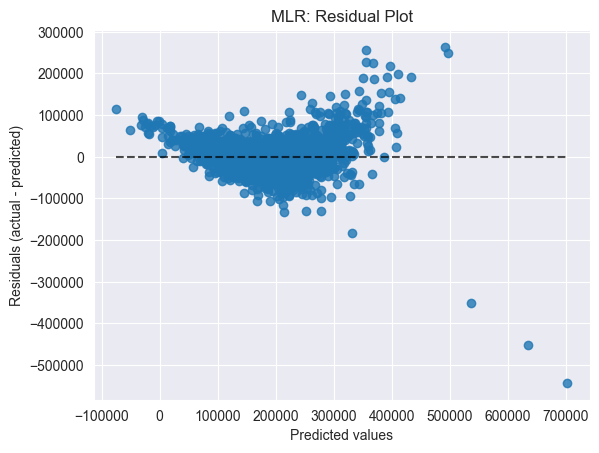

In [205]:
# Diagnostic plot: residual plot.
# Run this after you have created mlr_y_pred above.

from sklearn.metrics import PredictionErrorDisplay

# TODO: uncomment and run after completing the previous cell.
display = PredictionErrorDisplay(y_true=y, y_pred=mlr_y_pred)
display.plot()
plt.title('MLR: Residual Plot')
plt.show()

# 横轴：Predicted values 预测房价 y^
# 纵轴：Residuals (actual - predicted) 残差： y - y^

<div style="background-color: #fff899; padding: 10px; border-radius: 5px;">
  <h3 style="color: #0056b3;">Step 5. Reflection / Exit Ticket</h3>
  <p>Answer these questions in 2-4 sentences each:</p>
  <ol>
    <li>Is the MLR model better than the SLR model? Use R^2 and RMSE to justify your answer.</li>
    <li>Which predictor has the strongest evidence of being useful? How can you tell from the summary?</li>
    <li>Look at the actual-vs-predicted plot. What pattern or limitation do you notice?</li>
    <li>What is one way this model could be improved in a future lab?</li>
  </ol>
</div>

1. Yes. SLR 可以解释约 49.93% 的房价变化; MLR 可以解释约 76.49% 的房价变化; The MLR model is better than the SLR model. MLR achieves a higher R² (0.7649 vs. 0.4993) and a lower RMSE ($38,721.38 vs. $56,510.95), indicating better explanatory power and prediction accuracy.

2. The strongest predictor is the variable with the smallest p-value and largest absolute t-statistic in the regression summary. Overall Qual has the strongest evidence of being useful because it has the largest absolute t-statistic (39.597) and a very small p-value (<0.001).

3. The actual-vs-predicted plot shows that predictions are generally close to actual values, but the model has larger errors for high-priced houses and may underestimate some expensive properties.

4. The model could be improved by adding more relevant features, such as neighborhood information, house age, or additional property characteristics.